# M6 Semantic Analysis

This notebook reproduces the semantic analysis pipeline:
- sentence embeddings
- STS within/cross-class scoring
- UMAP + HDBSCAN clustering
- cross-model comparison report

Artifacts are written to `data/artifacts/`.

In [1]:
from pathlib import Path
import json
import random

import numpy as np
import pandas as pd
import yaml

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
CONFIG_PATH = ROOT / "configs" / "semantic.yaml"
PREPROCESS_CONFIG_PATH = ROOT / "configs" / "preprocessing.yaml"

with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

cfg

{'seed': 42,
 'data': {'test_path': 'data/processed/test.csv',
  'text_col': 'text',
  'label_col': 'label_id',
  'sample_size': None,
  'sample_seed': 42},
 'embeddings': {'model_name': 'all-MiniLM-L6-v2',
  'batch_size': 64,
  'device': None,
  'cache_path': 'data/artifacts/semantic_embeddings.npy'},
 'sts': {'pairs_per_class': 50, 'seed': 42},
 'clustering': {'umap': {'n_components': 2,
   'n_neighbors': 30,
   'min_dist': 0.05,
   'metric': 'cosine',
   'random_state': 42},
  'hdbscan': {'min_cluster_size': 120,
   'min_samples': 10,
   'metric': 'euclidean',
   'cluster_selection_method': 'eom'}},
 'comparison': {'bilstm_metrics': 'data/artifacts/bilstm_metrics.json',
  'bertweet_metrics': 'data/artifacts/bertweet_metrics.json'},
 'output': {'artifacts_dir': 'data/artifacts',
  'sts_report_name': 'sts_report.json',
  'cluster_plot_name': 'semantic_cluster_plot.png',
  'comparison_report_name': 'comparison_report.json',
  'embeddings_2d_name': 'semantic_embeddings_2d.npy'}}

In [2]:
data_cfg = cfg["data"]

test_path = ROOT / data_cfg["test_path"]
if not test_path.exists():
    raise FileNotFoundError(f"Missing test file: {test_path}")

df = pd.read_csv(test_path)
sample_size = data_cfg.get("sample_size")
if sample_size and sample_size < len(df):
    df = df.sample(n=sample_size, random_state=data_cfg.get("sample_seed", 42)).reset_index(drop=True)

text_col = data_cfg["text_col"]
label_col = data_cfg["label_col"]
texts = df[text_col].astype(str).tolist()
labels = df[label_col].astype(int).tolist()

len(df), df.head(2)

(10701,
                                                 text       label  label_id
 0  "you are not depressed, depression comes, it g...  Depression         1
 1  2 years ago i tried to suicide, for like 4 tim...    Suicidal         6)

In [3]:
label_map = {}
if PREPROCESS_CONFIG_PATH.exists():
    with open(PREPROCESS_CONFIG_PATH, "r", encoding="utf-8") as f:
        pre_cfg = yaml.safe_load(f)
    raw_map = pre_cfg.get("label_map", {})
    for name, lid in raw_map.items():
        if lid not in label_map:
            label_map[lid] = name.title()
if not label_map:
    label_map = {i: str(i) for i in sorted(set(labels))}

label_map

{0: 'Normal',
 1: 'Depression',
 2: 'Anxiety',
 3: 'Bipolar',
 4: 'Personality Disorder',
 5: 'Stress',
 6: 'Suicidal'}

In [4]:
from sentence_transformers import SentenceTransformer

emb_cfg = cfg["embeddings"]
cache_path = ROOT / emb_cfg.get("cache_path", "data/artifacts/semantic_embeddings.npy")
cache_path.parent.mkdir(parents=True, exist_ok=True)

if cache_path.exists():
    embeddings = np.load(cache_path)
else:
    model = SentenceTransformer(emb_cfg["model_name"], device=emb_cfg.get("device"))
    embeddings = model.encode(
        texts,
        batch_size=emb_cfg.get("batch_size", 64),
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True,
    )
    np.save(cache_path, embeddings)

embeddings.shape

c:\Users\Celine\miniconda3\envs\nlp\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(10701, 384)

In [5]:
def cosine_similarity(a: np.ndarray, b: np.ndarray) -> float:
    return float(np.dot(a, b))


def run_sts(embeddings: np.ndarray, labels: list[int], label_map: dict[int, str], pairs_per_class: int, seed: int = 42):
    rng = random.Random(seed)

    label_to_indices = {}
    for idx, lbl in enumerate(labels):
        label_to_indices.setdefault(lbl, []).append(idx)

    within_class_scores = {}
    for lbl, indices in sorted(label_to_indices.items()):
        if len(indices) < 2:
            continue
        pairs = [(rng.choice(indices), rng.choice(indices)) for _ in range(pairs_per_class)]
        scores = [cosine_similarity(embeddings[i], embeddings[j]) for i, j in pairs if i != j]
        if scores:
            within_class_scores[label_map.get(lbl, str(lbl))] = round(float(np.mean(scores)), 4)

    class_ids = sorted(label_to_indices.keys())
    cross_class_scores = []
    for _ in range(pairs_per_class * len(class_ids)):
        if len(class_ids) < 2:
            break
        c1, c2 = rng.sample(class_ids, 2)
        i = rng.choice(label_to_indices[c1])
        j = rng.choice(label_to_indices[c2])
        cross_class_scores.append(cosine_similarity(embeddings[i], embeddings[j]))

    return {
        "within_class_avg_cosine": within_class_scores,
        "cross_class_avg_cosine": round(float(np.mean(cross_class_scores)), 4) if cross_class_scores else None,
        "interpretation": (
            "Higher within-class scores indicate semantically cohesive groups. "
            "A larger within/cross-class gap suggests cleaner semantic boundaries."
        ),
    }

sts_cfg = cfg.get("sts", {})
sts_report = run_sts(
    embeddings=embeddings,
    labels=labels,
    label_map=label_map,
    pairs_per_class=sts_cfg.get("pairs_per_class", 50),
    seed=sts_cfg.get("seed", cfg.get("seed", 42)),
)
sts_report

{'within_class_avg_cosine': {'Normal': 0.0832,
  'Depression': 0.2836,
  'Anxiety': 0.2209,
  'Bipolar': 0.238,
  'Personality Disorder': 0.1818,
  'Stress': 0.1553,
  'Suicidal': 0.2958},
 'cross_class_avg_cosine': 0.1405,
 'interpretation': 'Higher within-class scores indicate semantically cohesive groups. A larger within/cross-class gap suggests cleaner semantic boundaries.'}

c:\Users\Celine\miniconda3\envs\nlp\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


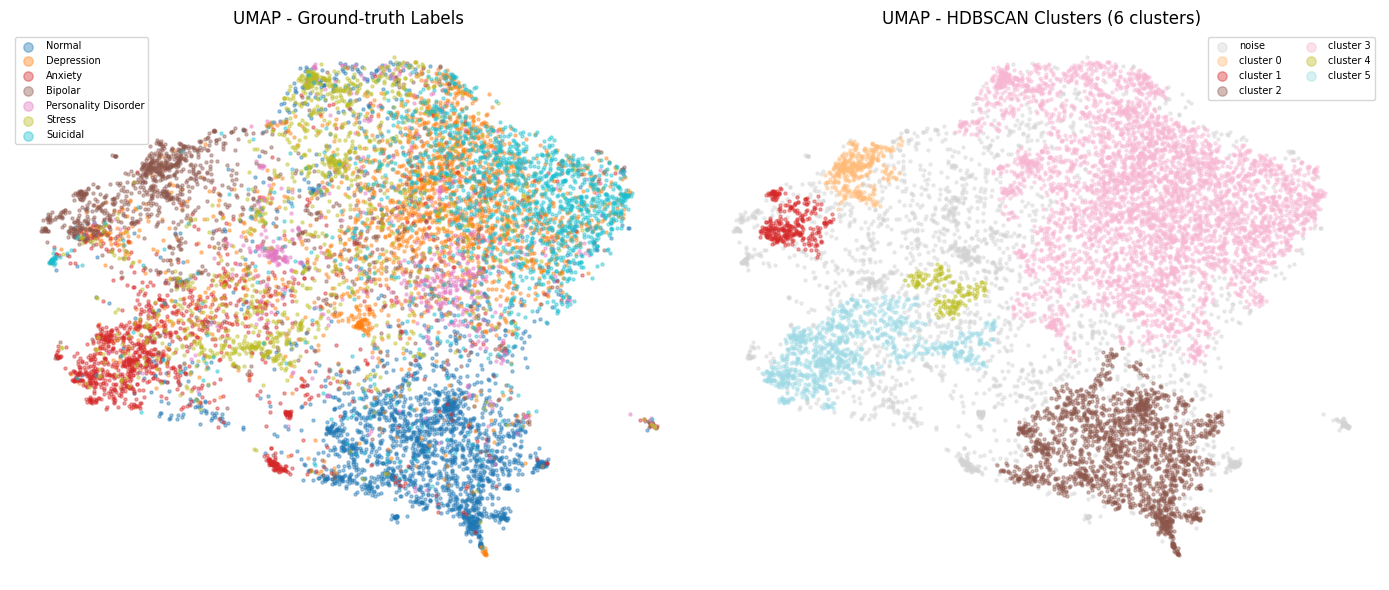

(6, 0.1968040370058873)

In [6]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import umap
import hdbscan

cluster_cfg = cfg["clustering"]
artifacts_dir = ROOT / cfg["output"]["artifacts_dir"]
artifacts_dir.mkdir(parents=True, exist_ok=True)

umap_model = umap.UMAP(
    n_components=cluster_cfg["umap"].get("n_components", 2),
    n_neighbors=cluster_cfg["umap"].get("n_neighbors", 15),
    min_dist=cluster_cfg["umap"].get("min_dist", 0.1),
    metric=cluster_cfg["umap"].get("metric", "cosine"),
    random_state=cluster_cfg["umap"].get("random_state", cfg.get("seed", 42)),
)
embeddings_2d = umap_model.fit_transform(embeddings)

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=cluster_cfg["hdbscan"].get("min_cluster_size", 30),
    min_samples=cluster_cfg["hdbscan"].get("min_samples", 5),
    metric=cluster_cfg["hdbscan"].get("metric", "euclidean"),
    cluster_selection_method=cluster_cfg["hdbscan"].get("cluster_selection_method", "eom"),
)
cluster_ids = clusterer.fit_predict(embeddings_2d)

n_clusters = len(set(cluster_ids)) - (1 if -1 in cluster_ids else 0)
noise_ratio = float(np.mean(cluster_ids == -1))

unique_labels = sorted(set(labels))
colors = cm.tab10(np.linspace(0, 1, len(unique_labels)))
label_color = {lbl: colors[i] for i, lbl in enumerate(unique_labels)}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for lbl in unique_labels:
    mask = np.array(labels) == lbl
    axes[0].scatter(
        embeddings_2d[mask, 0],
        embeddings_2d[mask, 1],
        c=[label_color[lbl]],
        label=label_map.get(lbl, str(lbl)),
        alpha=0.4,
        s=5,
    )
axes[0].set_title("UMAP - Ground-truth Labels")
axes[0].legend(markerscale=3, fontsize=7, loc="best")
axes[0].axis("off")

unique_clusters = sorted(set(cluster_ids))
cluster_colors = cm.tab20(np.linspace(0, 1, max(len(unique_clusters), 1)))
for i, cid in enumerate(unique_clusters):
    mask = cluster_ids == cid
    color = "lightgrey" if cid == -1 else cluster_colors[i]
    label_text = "noise" if cid == -1 else f"cluster {cid}"
    axes[1].scatter(
        embeddings_2d[mask, 0],
        embeddings_2d[mask, 1],
        c=[color],
        label=label_text,
        alpha=0.4,
        s=5,
    )
axes[1].set_title(f"UMAP - HDBSCAN Clusters ({n_clusters} clusters)")
axes[1].legend(markerscale=3, fontsize=7, loc="best", ncol=2)
axes[1].axis("off")

plt.tight_layout()
plt.show()

n_clusters, noise_ratio

In [7]:
metrics_keys = ["accuracy", "macro_f1", "weighted_f1"]
comparison_cfg = cfg.get("comparison", {})
comparison_report = {"models": {}}

for model_key, metrics_path in comparison_cfg.items():
    if not metrics_path:
        continue
    p = ROOT / metrics_path
    if not p.exists():
        continue
    with open(p, "r", encoding="utf-8") as f:
        m = json.load(f)
    comparison_report["models"][model_key] = {k: m.get(k) for k in metrics_keys}
    comparison_report["models"][model_key]["per_class"] = m.get("per_class", {})

ranked = sorted(
    [(k, v.get("macro_f1") or 0.0) for k, v in comparison_report["models"].items()],
    key=lambda x: x[1],
    reverse=True,
)
comparison_report["ranking_by_macro_f1"] = [k for k, _ in ranked]

comparison_report

{'models': {'bilstm_metrics': {'accuracy': 0.8244,
   'macro_f1': 0.8359,
   'weighted_f1': 0.8248,
   'per_class': {'Normal': {'precision': 0.9117,
     'recall': 0.9159,
     'f1': 0.9138,
     'support': 2401},
    'Depression': {'precision': 0.7417,
     'recall': 0.6928,
     'f1': 0.7164,
     'support': 2246},
    'Anxiety': {'precision': 0.8456,
     'recall': 0.8993,
     'f1': 0.8716,
     'support': 1291},
    'Bipolar': {'precision': 0.9328,
     'recall': 0.8932,
     'f1': 0.9126,
     'support': 1274},
    'Personality Disorder': {'precision': 0.9185,
     'recall': 0.8906,
     'f1': 0.9043,
     'support': 658},
    'Stress': {'precision': 0.859,
     'recall': 0.8424,
     'f1': 0.8506,
     'support': 1244},
    'Suicidal': {'precision': 0.6517,
     'recall': 0.7146,
     'f1': 0.6817,
     'support': 1587}}},
  'bertweet_metrics': {'accuracy': 0.821,
   'macro_f1': 0.8268,
   'weighted_f1': 0.8209,
   'per_class': {'Normal': {'precision': 0.9512,
     'recall': 0.9

In [8]:
output_cfg = cfg["output"]

sts_path = artifacts_dir / output_cfg["sts_report_name"]
with open(sts_path, "w", encoding="utf-8") as f:
    json.dump(sts_report, f, indent=2)

emb2d_path = artifacts_dir / output_cfg["embeddings_2d_name"]
np.save(emb2d_path, embeddings_2d)

plot_path = artifacts_dir / output_cfg["cluster_plot_name"]
fig.savefig(plot_path, dpi=120, bbox_inches="tight")

comparison_path = artifacts_dir / output_cfg["comparison_report_name"]
with open(comparison_path, "w", encoding="utf-8") as f:
    json.dump(comparison_report, f, indent=2)

{
    "sts_report": str(sts_path),
    "embeddings_2d": str(emb2d_path),
    "cluster_plot": str(plot_path),
    "comparison_report": str(comparison_path),
}

{'sts_report': 'D:\\sentimind\\data\\artifacts\\sts_report.json',
 'embeddings_2d': 'D:\\sentimind\\data\\artifacts\\semantic_embeddings_2d.npy',
 'cluster_plot': 'D:\\sentimind\\data\\artifacts\\semantic_cluster_plot.png',
 'comparison_report': 'D:\\sentimind\\data\\artifacts\\comparison_report.json'}